In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('/content/Opportunity Data.csv')
print(df['Opportunity Category'].unique())

['Course' 'Competition' 'Internship' 'Event' 'Engagement']


In [ ]:
df.head()

,Learner SignUp DateTime,Month,Year,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Age,...,Major Category,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date,Opportunity Duration(OD),Normalized OD,Entry Lag (EL),Normalized EL
0,06/14/2023 12:30:35,June,2023,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Faria,01/12/2001,23,...,Health Sciences,03/11/2024 12:01:41,Started,1080,6/14/2023 12:36,11/03/2022 18:30:39,841,0.882108,460,0.657
1,05/01/2023 05:29:16,January,2023,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Poojitha,08/16/2000,24,...,Computer & IT,03/11/2024 12:01:41,Started,1080,05/01/2023 06:08:21,11/03/2022 18:30:39,841,0.882108,299,0.555
2,04/09/2023 20:35:08,September,2023,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Emmanuel,01/27/2002,23,...,Computer & IT,03/11/2024 12:01:41,Started,1080,05/11/2023 708:21:29,11/03/2022 18:30:39,841,0.882108,603,0.749
3,08/29/2023 05:20:03,August,2023,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Amrutha Varshini,11/01/1999,26,...,Computer & IT,03/11/2024 12:01:41,Team Allocated,1070,10/09/2023 22:02:42,11/03/2022 18:30:39,841,0.882108,548,0.714
4,01/06/2023 15:26:36,June,2023,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Vinay Varshith,04/19/2000,25,...,Computer & IT,03/11/2024 12:01:41,Started,1080,01/06/2023 15:40:10,11/03/2022 18:30:39,841,0.882108,447,0.649


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Learner SignUp DateTime   8558 non-null   object 
 1   Month                     8558 non-null   object 
 2   Year                      8558 non-null   int64  
 3   Opportunity Id            8558 non-null   object 
 4   Opportunity Name          8558 non-null   object 
 5   Opportunity Category      8558 non-null   object 
 6   Opportunity End Date      8558 non-null   object 
 7   First Name                8558 non-null   object 
 8   Date of Birth             8558 non-null   object 
 9   Age                       8558 non-null   int64  
 10  Age Bin                   8558 non-null   object 
 11  Gender                    8558 non-null   object 
 12  Gender Code               8558 non-null   int64  
 13  Country                   8558 non-null   object 
 14  Region  

In [ ]:
print(df.isnull().sum())

Learner SignUp DateTime      0
Month                        0
Year                         0
Opportunity Id               0
Opportunity Name             0
Opportunity Category         0
Opportunity End Date         0
First Name                   0
Date of Birth                0
Age                          0
Age Bin                      0
Gender                       0
Gender Code                  0
Country                      0
Region                      36
Institution Name             1
Current/Intended Major       5
Major Category               0
Entry created at             0
Status Description           0
Status Code                  0
Apply Date                   0
Opportunity Start Date       0
Opportunity Duration(OD)     0
Normalized OD                0
Entry Lag (EL)               0
Normalized EL                0
dtype: int64


In [ ]:
df.describe()

,Year,Age,Gender Code,Status Code,Opportunity Duration(OD),Normalized OD,Entry Lag (EL),Normalized EL
count,8558.000000,8558.000000,8558.000000,8558.000000,8558.000000,8558.000000,8558.000000,8558.000000
mean,2023.323323,25.288385,0.586352,1052.225987,312.709628,0.391387,32.511218,0.384630
std,0.467772,4.393923,0.492516,21.665207,276.751377,0.257061,283.719923,0.180996
min,2023.000000,6.000000,0.000000,1010.000000,-109.000000,0.000000,-570.000000,0.000000
25%,2023.000000,23.000000,0.000000,1030.000000,95.000000,0.189027,-164.000000,0.259000
50%,2023.000000,25.000000,1.000000,1050.000000,258.000000,0.340517,-2.000000,0.363000
75%,2024.000000,27.000000,1.000000,1070.000000,469.000000,0.536279,186.000000,0.482750
max,2024.000000,58.000000,1.000000,1120.000000,968.000000,1.000000,997.000000,1.000000


/tmp/ipython-input-3252673220.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Region '].fillna(df['Region '].mode()[0], inplace=True)


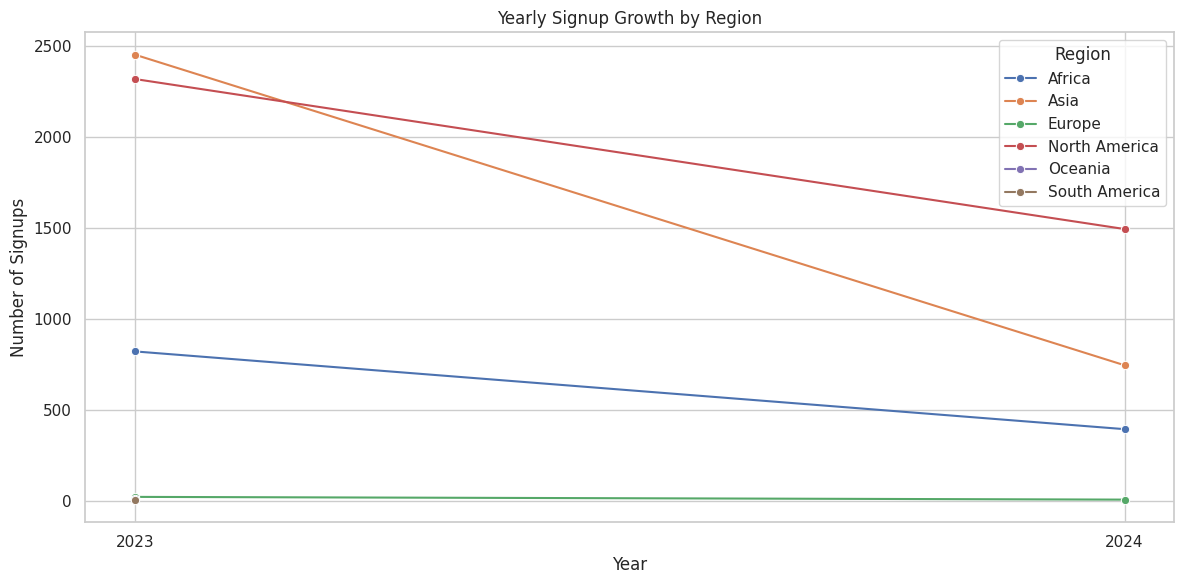

In [ ]:
# Convert 'Learner SignUp DateTime' to datetime, coercing errors to NaT
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')

# Drop rows with invalid dates
df.dropna(subset=['Learner SignUp DateTime'], inplace=True)

# Fill missing values in 'Region' with the mode
df['Region '].fillna(df['Region '].mode()[0], inplace=True)

# Extract year
df['Signup Year'] = df['Learner SignUp DateTime'].dt.year

# Group by Region and Signup Year
region_year_counts = df.groupby(['Region ', 'Signup Year']).size().reset_index(name='Signup Count')

# Set plot style
sns.set(style="whitegrid")

# Plot line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=region_year_counts, x='Signup Year', y='Signup Count', hue='Region ', marker='o')

plt.title('Yearly Signup Growth by Region')
plt.xlabel('Year')
plt.ylabel('Number of Signups')
plt.xticks(region_year_counts['Signup Year'].unique())  # Ensure each year is shown
plt.legend(title='Region')
plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

Index(['Learner SignUp DateTime', 'Month', 'Year', 'Opportunity Id',
       'Opportunity Name', 'Opportunity Category', 'Opportunity End Date',
       'First Name', 'Date of Birth', 'Age', 'Age Bin', 'Gender',
       'Gender Code', 'Country', 'Region ', 'Institution Name',
       'Current/Intended Major', 'Major Category ', 'Entry created at',
       'Status Description', 'Status Code', 'Apply Date',
       'Opportunity Start Date', 'Opportunity Duration(OD)', 'Normalized OD',
       'Entry Lag (EL)', 'Normalized EL', 'Signup Year'],
      dtype='object')


/tmp/ipython-input-2994688567.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, y='Major Category ', x='Percentage', palette='viridis')


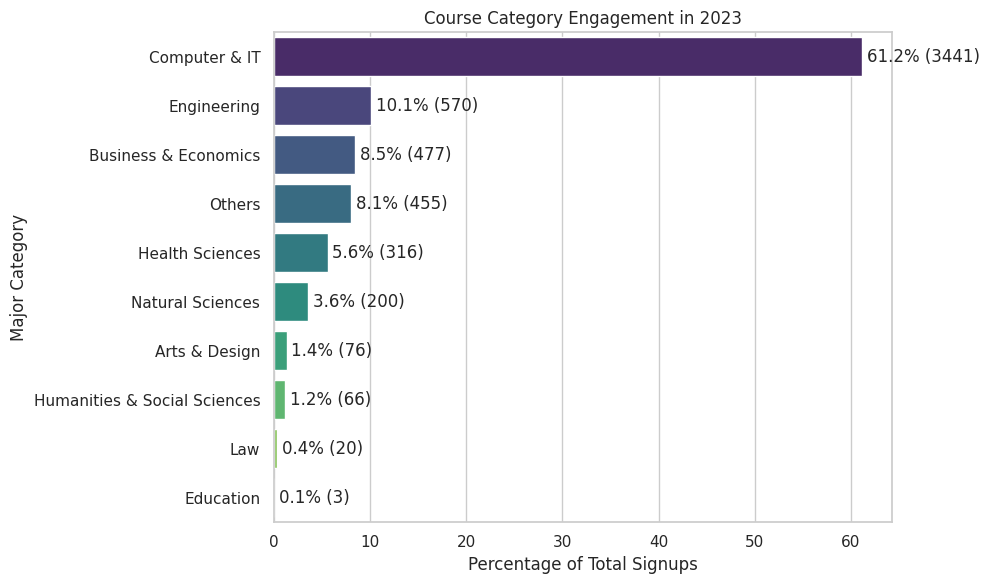

/tmp/ipython-input-2994688567.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, y='Major Category ', x='Percentage', palette='viridis')


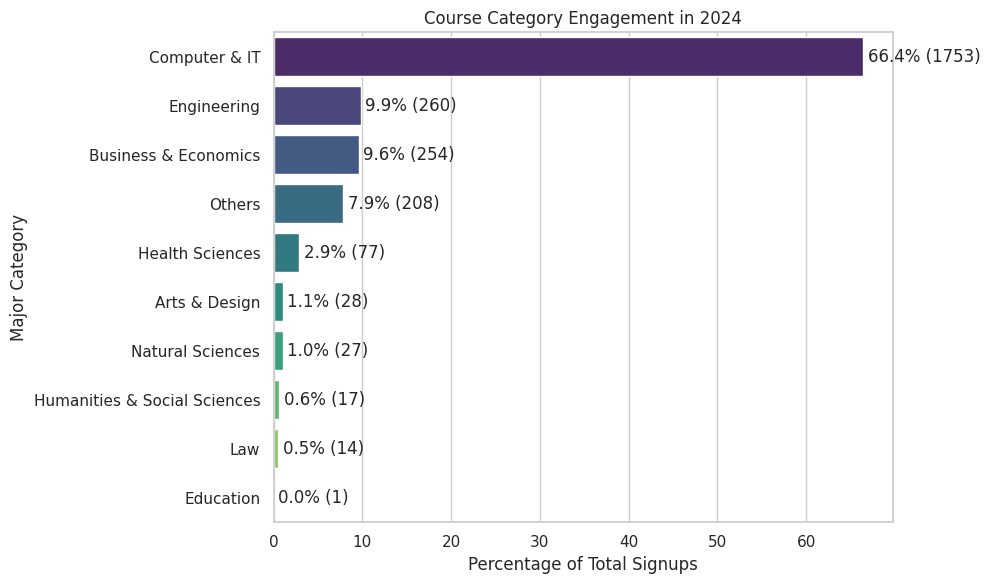

In [ ]:
# Clean course category if needed
df['Major Category '] = df['Major Category '].fillna('Unknown')

# Group by year and category, then count
category_year_counts = df.groupby(['Signup Year', 'Major Category ']).size().reset_index(name='Count')

# Calculate percentages
category_year_counts['Year Total'] = category_year_counts.groupby('Signup Year')['Count'].transform('sum')
category_year_counts['Percentage'] = (category_year_counts['Count'] / category_year_counts['Year Total']) * 100

# Sort values for each year
category_year_counts = category_year_counts.sort_values(by=['Signup Year', 'Count'], ascending=[True, False])

# Plot one horizontal bar chart per year
years = category_year_counts['Signup Year'].unique()

for year in years:
    data = category_year_counts[category_year_counts['Signup Year'] == year]

    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, y='Major Category ', x='Percentage', palette='viridis')

    # Annotate bars with percentage and count
    for i, (index, row) in enumerate(data.iterrows()):
        plt.text(row['Percentage'] + 0.5, i,
                 f"{row['Percentage']:.1f}% ({int(row['Count'])})", va='center')

    plt.title(f'Course Category Engagement in {year}')
    plt.xlabel('Percentage of Total Signups')
    plt.ylabel('Major Category')
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-3283829260.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Age Bin', y='Count', palette='mako')


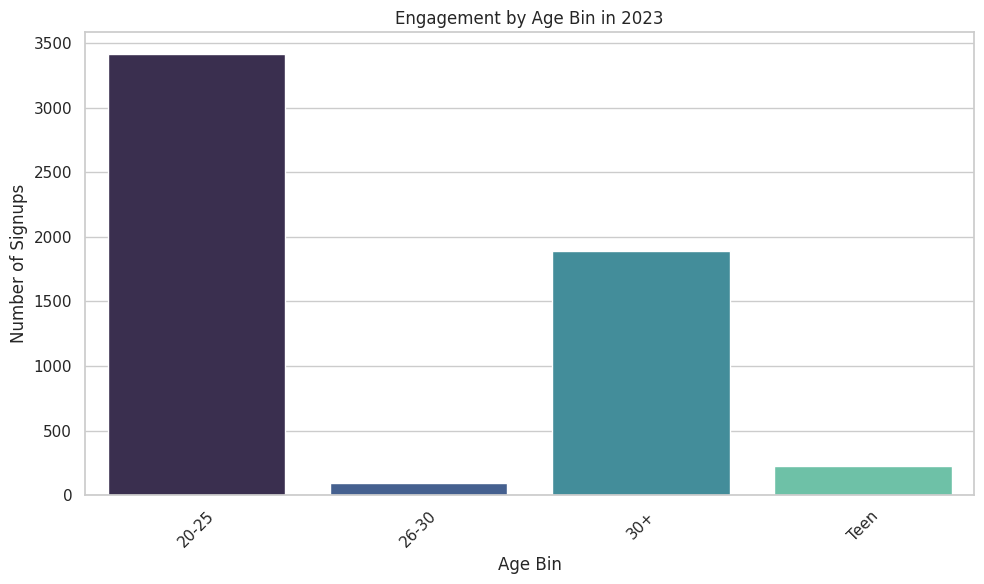

/tmp/ipython-input-3283829260.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Age Bin', y='Count', palette='mako')


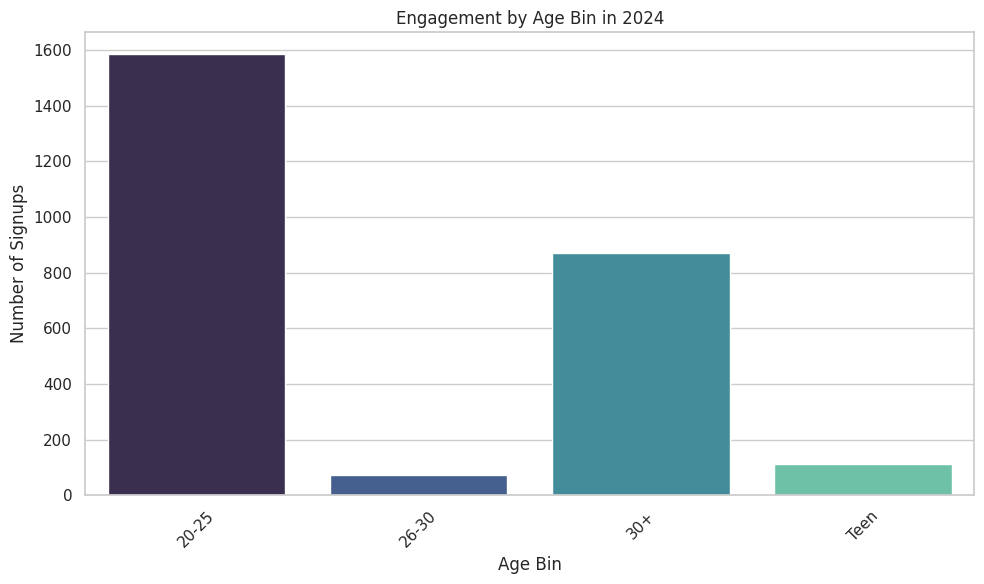

In [ ]:
# Extract year from 'Learner SignUp DateTime' if not already done
if 'Signup Year' not in df.columns:
    df['Signup Year'] = pd.to_datetime(df['Learner SignUp DateTime']).dt.year

# Group by Signup Year and Age Bin, then count
age_bin_counts = df.groupby(['Signup Year', 'Age Bin']).size().reset_index(name='Count')

# Get the unique years
years = age_bin_counts['Signup Year'].unique()

# Create a bar chart for each year
for year in years:
    if year in [2023, 2024]:
        data = age_bin_counts[age_bin_counts['Signup Year'] == year]

        plt.figure(figsize=(10, 6))
        sns.barplot(data=data, x='Age Bin', y='Count', palette='mako')
        plt.title(f'Engagement by Age Bin in {year}')
        plt.xlabel('Age Bin')
        plt.ylabel('Number of Signups')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
# Let's see the unique values in 'Status Description' to identify withdrawals
print(df['Status Description'].unique())

['Started' 'Team Allocated' 'Waitlisted' 'Withdraw' 'Rewards Award'
 'Dropped Out' 'Rejected' 'Applied']


/tmp/ipython-input-3312231959.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_withdrawals, x='Region ', y='Withdrawal Count', palette='plasma')


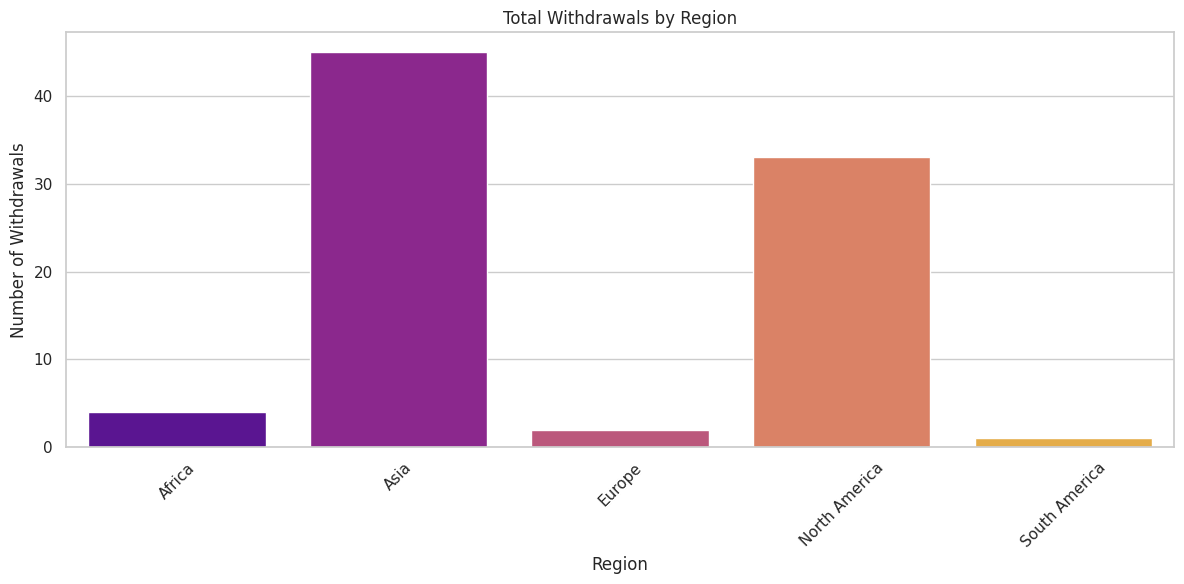

In [ ]:
# Filter for 'Withdrawn' status
withdrawn_df = df[df['Status Description'] == 'Withdraw']

# Group by Region and count withdrawals
region_withdrawals = withdrawn_df.groupby('Region ')['Opportunity Id'].count().reset_index()
region_withdrawals.rename(columns={'Opportunity Id': 'Withdrawal Count'}, inplace=True)

# Create bar chart for withdrawals by region
plt.figure(figsize=(12, 6))
sns.barplot(data=region_withdrawals, x='Region ', y='Withdrawal Count', palette='plasma')
plt.title('Total Withdrawals by Region')
plt.xlabel('Region')
plt.ylabel('Number of Withdrawals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1603021413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_withdrawals, y='Major Category ', x='Withdrawal Count', palette='magma')


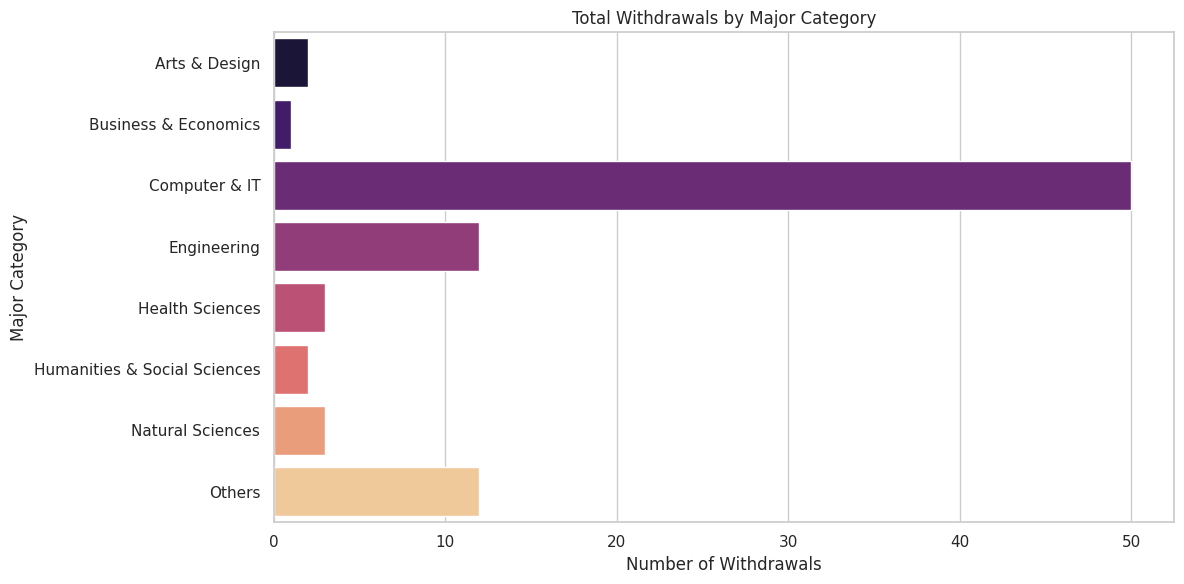

In [ ]:
# Group by Major Category and count withdrawals
category_withdrawals = withdrawn_df.groupby('Major Category ')['Opportunity Id'].count().reset_index()
category_withdrawals.rename(columns={'Opportunity Id': 'Withdrawal Count'}, inplace=True)

# Create bar chart for withdrawals by major category
plt.figure(figsize=(12, 6))
sns.barplot(data=category_withdrawals, y='Major Category ', x='Withdrawal Count', palette='magma')
plt.title('Total Withdrawals by Major Category')
plt.xlabel('Number of Withdrawals')
plt.ylabel('Major Category')
plt.tight_layout()
plt.show()

/tmp/ipython-input-4153806332.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_withdrawals, x='Gender', y='Withdrawal Count', palette='cividis')


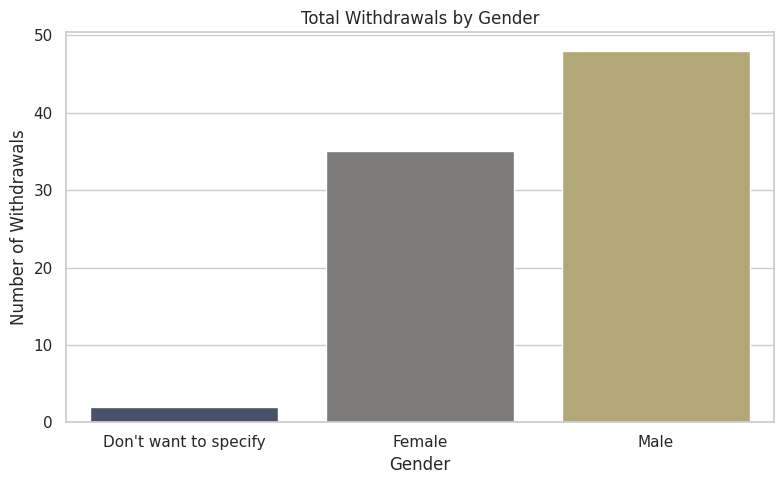

In [ ]:
# Group by Gender and count withdrawals
gender_withdrawals = withdrawn_df.groupby('Gender')['Opportunity Id'].count().reset_index()
gender_withdrawals.rename(columns={'Opportunity Id': 'Withdrawal Count'}, inplace=True)

# Create bar chart for withdrawals by gender
plt.figure(figsize=(8, 5))
sns.barplot(data=gender_withdrawals, x='Gender', y='Withdrawal Count', palette='cividis')
plt.title('Total Withdrawals by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Withdrawals')
plt.tight_layout()
plt.show()

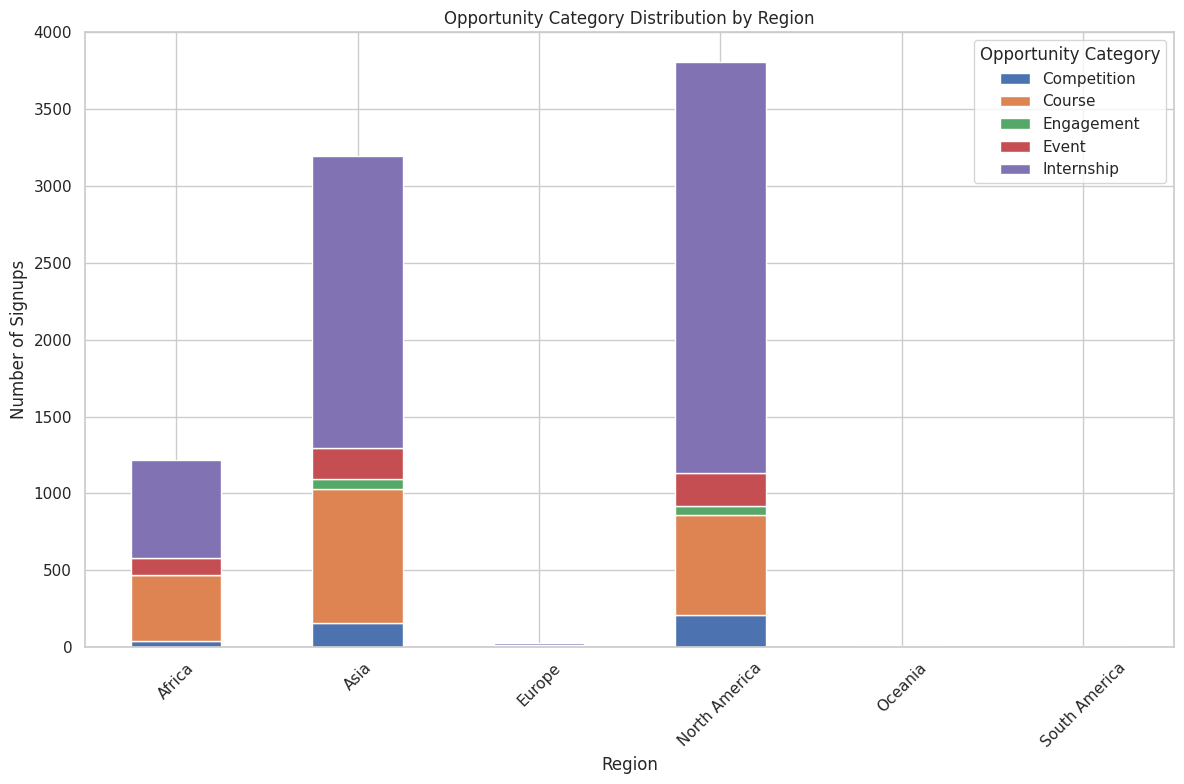

In [ ]:
# Create a pivot table to count the number of signups for each Region and Opportunity Category
region_category_counts = df.groupby(['Region ', 'Opportunity Category']).size().unstack(fill_value=0)

# Create the stacked bar chart
region_category_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Opportunity Category Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Signups')
plt.xticks(rotation=45)
plt.legend(title='Opportunity Category')
plt.tight_layout()
plt.show()

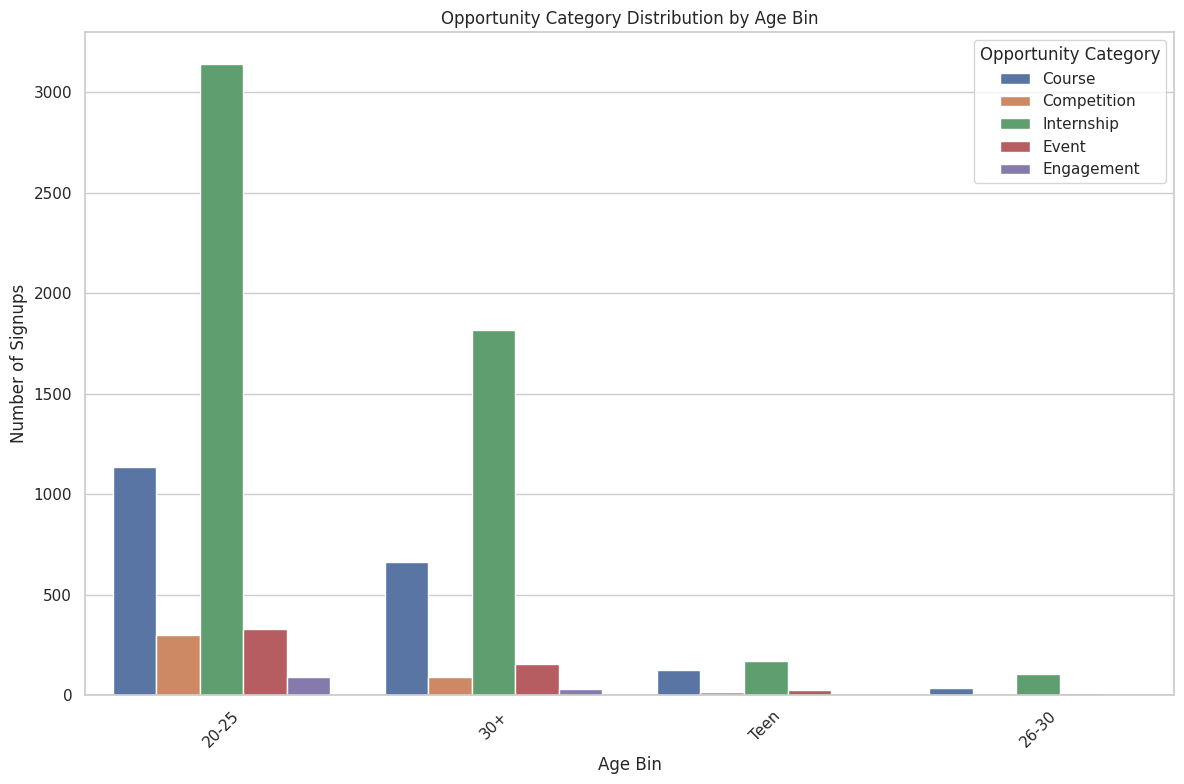

In [ ]:
# Create a grouped bar chart to show the count of opportunity categories for different age bins
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Age Bin', hue='Opportunity Category')
plt.title('Opportunity Category Distribution by Age Bin')
plt.xlabel('Age Bin')
plt.ylabel('Number of Signups')
plt.xticks(rotation=45)
plt.legend(title='Opportunity Category')
plt.tight_layout()
plt.show()

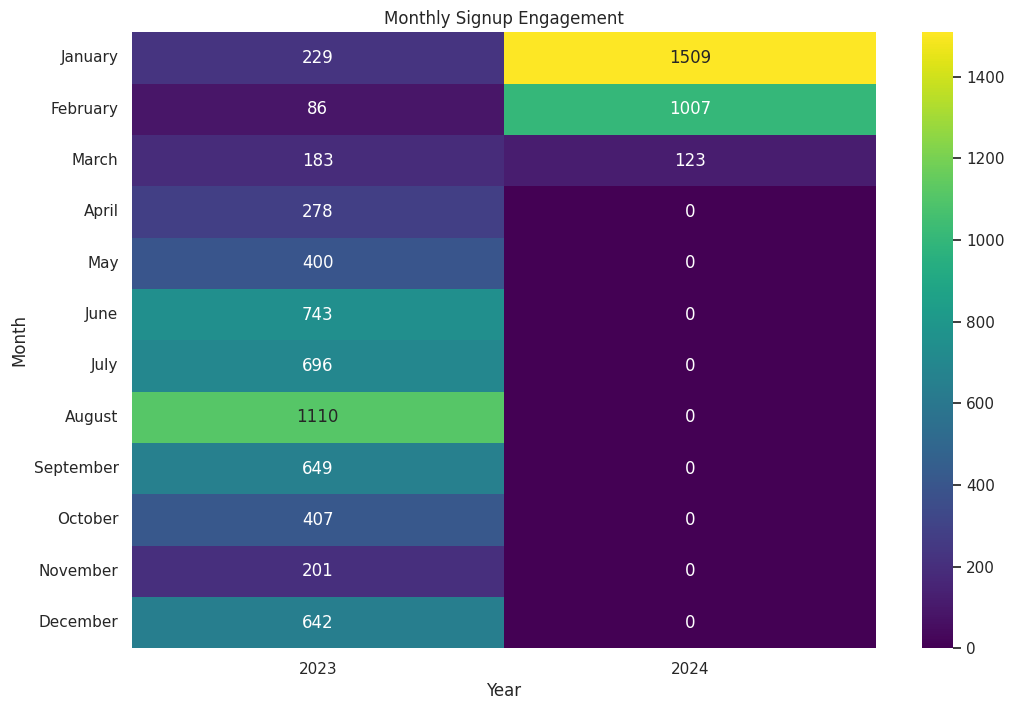

In [ ]:
# Convert 'Learner SignUp DateTime' to datetime, coercing errors to NaT
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')

# Drop rows with invalid dates
df.dropna(subset=['Learner SignUp DateTime'], inplace=True)

# Extract month and year from 'Learner SignUp DateTime'
df['Signup Month'] = df['Learner SignUp DateTime'].dt.month_name()
df['Signup Year'] = df['Learner SignUp DateTime'].dt.year

# Group by month and year and count signups
monthly_counts = df.groupby(['Signup Year', 'Signup Month'])['Learner SignUp DateTime'].count().reset_index(name='Signup Count')

# Create a pivot table for the heatmap
heatmap_data = monthly_counts.pivot_table(index='Signup Month', columns='Signup Year', values='Signup Count', fill_value=0)

# Sort the months chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = heatmap_data.reindex(months_order)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='viridis')
plt.title('Monthly Signup Engagement')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

In [ ]:
# Create interaction features
df['Age_Opportunity_Category'] = df['Age'].astype(str) + '_' + df['Opportunity Category'].astype(str)
df['Region_Major_Category'] = df['Region '].astype(str) + '_' + df['Major Category '].astype(str)

# Drop unnecessary columns
columns_to_drop = ['Opportunity Id', 'First Name', 'Date of Birth', 'Learner SignUp DateTime', 'Opportunity End Date', 'Opportunity Start Date', 'Apply Date']
df.drop(columns=columns_to_drop, inplace=True)

print("Interaction features created and unnecessary columns dropped.")
display(df.head())

Interaction features created and unnecessary columns dropped.


,Month,Year,Opportunity Name,Opportunity Category,Age,Age Bin,Gender,Gender Code,Country,Region,...,Status Description,Status Code,Opportunity Duration(OD),Normalized OD,Entry Lag (EL),Normalized EL,Signup Year,Signup Month,Age_Opportunity_Category,Region_Major_Category
0,June,2023,Career Essentials: Getting Started with Your P...,Course,23,20-25,Female,0,Pakistan,Asia,...,Started,1080,841,0.882108,460,0.657,2023,June,23_Course,Asia_Health Sciences
1,January,2023,Career Essentials: Getting Started with Your P...,Course,24,20-25,Female,0,India,Asia,...,Started,1080,841,0.882108,299,0.555,2023,May,24_Course,Asia_Computer & IT
2,September,2023,Career Essentials: Getting Started with Your P...,Course,23,20-25,Male,1,United States,North America,...,Started,1080,841,0.882108,603,0.749,2023,April,23_Course,North America_Computer & IT
3,August,2023,Career Essentials: Getting Started with Your P...,Course,26,30+,Female,0,United States,North America,...,Team Allocated,1070,841,0.882108,548,0.714,2023,August,26_Course,North America_Computer & IT
4,June,2023,Career Essentials: Getting Started with Your P...,Course,25,20-25,Male,1,United States,North America,...,Started,1080,841,0.882108,447,0.649,2023,January,25_Course,North America_Computer & IT


In [ ]:
df['Target'] = df['Status Description'].apply(lambda x: 1 if x in ['Withdraw', 'Dropped Out'] else 0)

# Display the mapping to verify
print(df[['Status Description', 'Target']].head(10))

# Display the value counts of the new 'Target' column
print("\nTarget variable distribution:")
print(df['Target'].value_counts())

  Status Description  Target
0            Started       0
1            Started       0
2            Started       0
3     Team Allocated       0
4            Started       0
5         Waitlisted       0
6           Withdraw       1
7     Team Allocated       0
8            Started       0
9     Team Allocated       0

Target variable distribution:
Target
0    7582
1     681
Name: count, dtype: int64


In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['Status Description', 'Target'])
y = df['Target']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Display the first few rows of the encoded features
display(X.head())

,Year,Age,Gender Code,Status Code,Opportunity Duration(OD),Normalized OD,Entry Lag (EL),Normalized EL,Signup Year,Month_August,...,Region_Major_Category_North America_Engineering,Region_Major_Category_North America_Health Sciences,Region_Major_Category_North America_Humanities & Social Sciences,Region_Major_Category_North America_Law,Region_Major_Category_North America_Natural Sciences,Region_Major_Category_North America_Others,Region_Major_Category_Oceania_Computer & IT,Region_Major_Category_Oceania_Others,Region_Major_Category_South America_Computer & IT,Region_Major_Category_South America_Engineering
0,2023,23,0,1080,841,0.882108,460,0.657,2023,False,...,False,False,False,False,False,False,False,False,False,False
1,2023,24,0,1080,841,0.882108,299,0.555,2023,False,...,False,False,False,False,False,False,False,False,False,False
2,2023,23,1,1080,841,0.882108,603,0.749,2023,False,...,False,False,False,False,False,False,False,False,False,False
3,2023,26,0,1070,841,0.882108,548,0.714,2023,True,...,False,False,False,False,False,False,False,False,False,False
4,2023,25,1,1080,841,0.882108,447,0.649,2023,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6610, 2572)
X_test shape: (1653, 2572)
y_train shape: (6610,)
y_test shape: (1653,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rfc.fit(X_train, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Resample the training data
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the resampled data
rfc.fit(X_train_res, y_train_res)

print("Model trained successfully on the under-sampled data.")

Model trained successfully on the under-sampled data.


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1517
           1       0.44      0.91      0.59       136

    accuracy                           0.90      1653
   macro avg       0.72      0.90      0.77      1653
weighted avg       0.95      0.90      0.91      1653


Confusion Matrix:


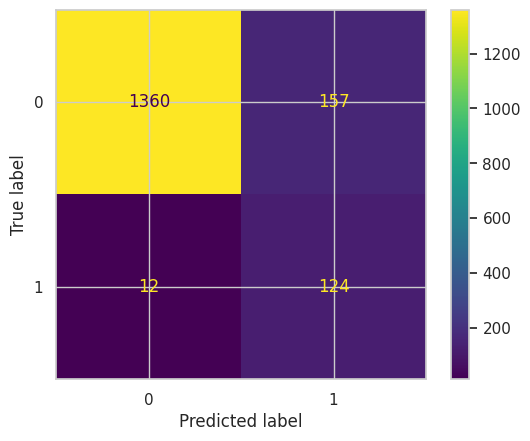

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test data
y_pred = rfc.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate and display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

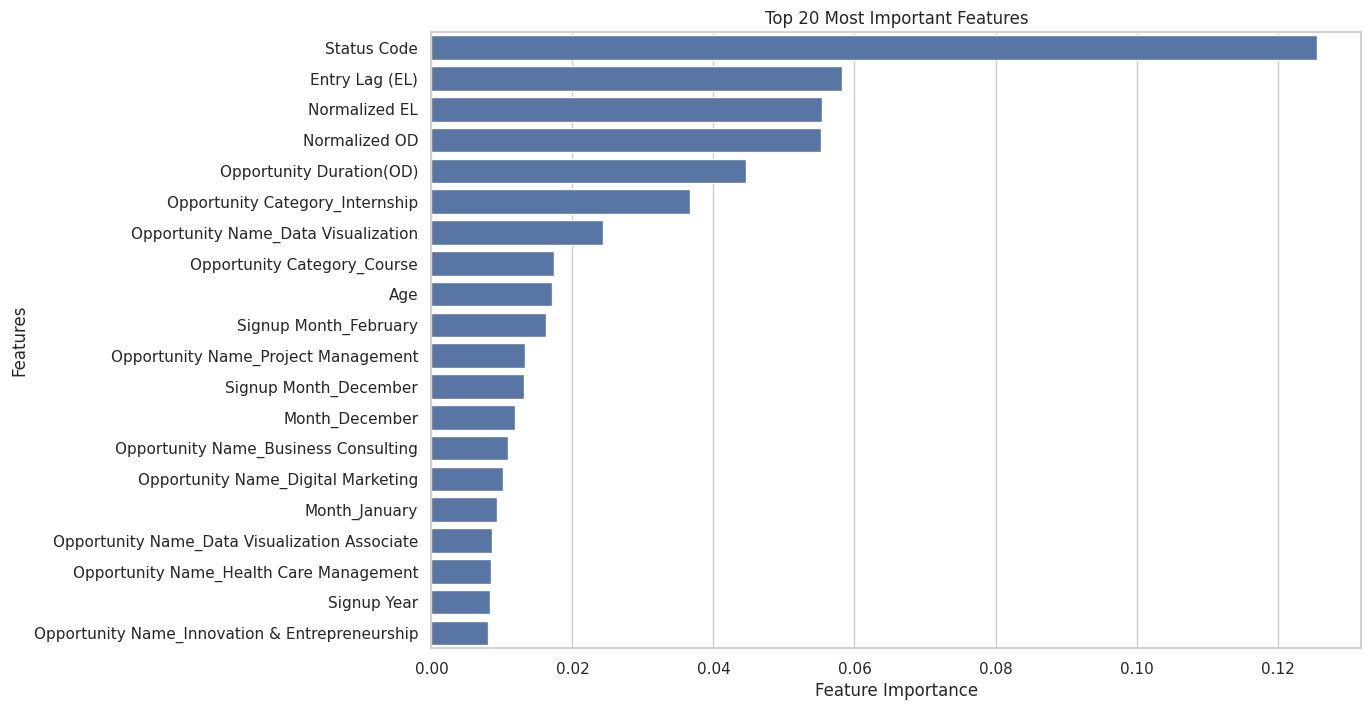

In [ ]:
# Get feature importances from the trained model
importances = rfc.feature_importances_
feature_names = X_train_res.columns

# Create a pandas series for easy sorting and plotting
feature_importance_series = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importances = feature_importance_series.sort_values(ascending=False)

# Plot the top 20 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.head(20), y=sorted_importances.head(20).index)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 20 Most Important Features")
plt.show()

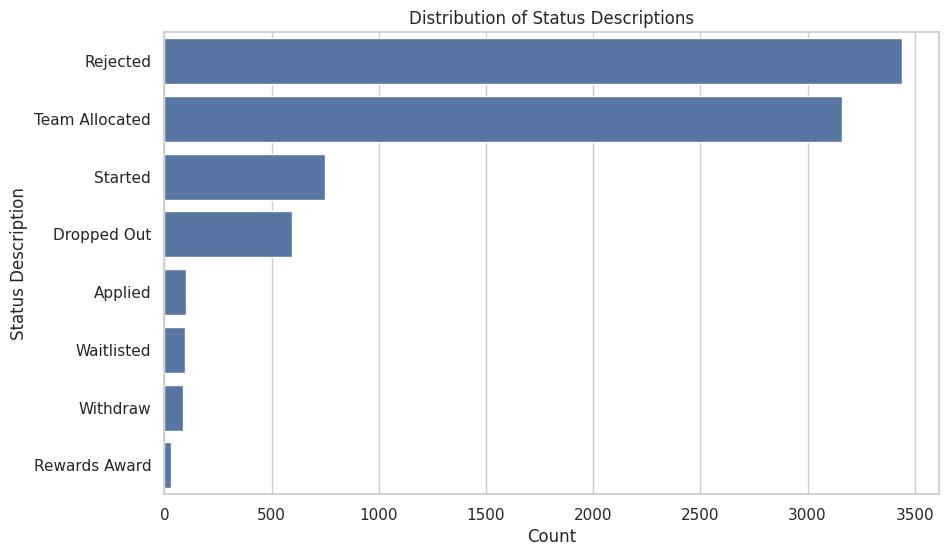

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Status Description', order = df['Status Description'].value_counts().index)
plt.title('Distribution of Status Descriptions')
plt.xlabel('Count')
plt.ylabel('Status Description')
plt.show()

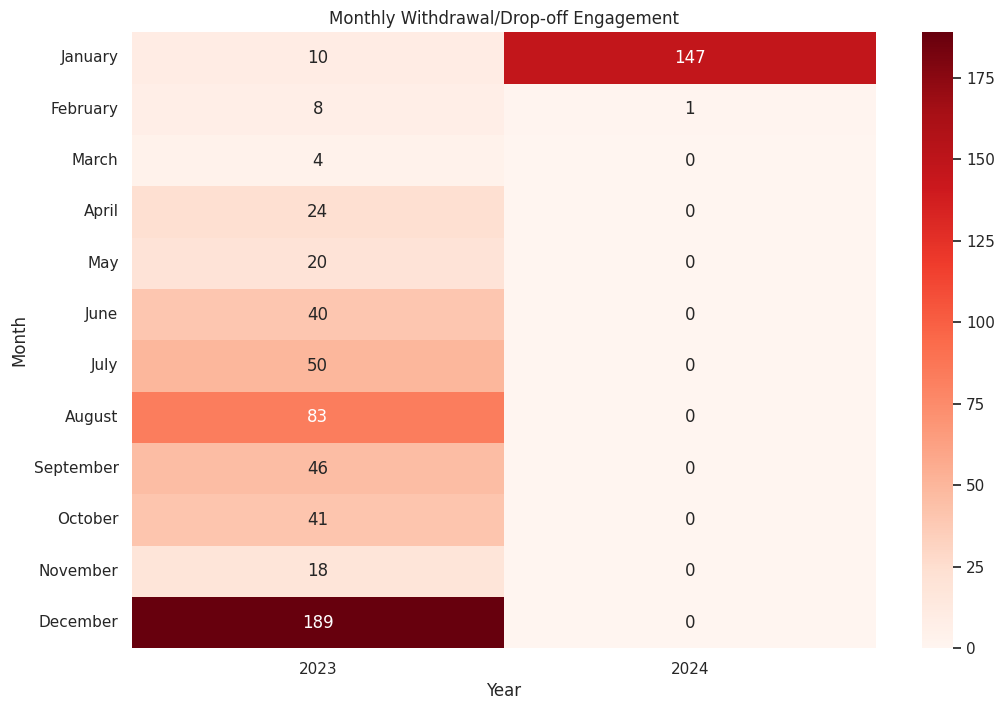

In [ ]:
# Filter for 'Withdrawn' and 'Dropped Out' statuses
withdrawn_df = df[df['Status Description'].isin(['Withdraw', 'Dropped Out'])]

# Group by month and year and count withdrawals
monthly_withdrawals = withdrawn_df.groupby(['Signup Year', 'Signup Month'])['Status Description'].count().reset_index(name='Withdrawal Count')

# Create a pivot table for the heatmap
heatmap_data_withdrawals = monthly_withdrawals.pivot_table(index='Signup Month', columns='Signup Year', values='Withdrawal Count', fill_value=0)

# Sort the months chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data_withdrawals = heatmap_data_withdrawals.reindex(months_order)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_withdrawals, annot=True, fmt='.0f', cmap='Reds')
plt.title('Monthly Withdrawal/Drop-off Engagement')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

Top 20 features correlated with Target:

Target                      1.000000
Status Code                 0.071872
Age                         0.016088
Gender Code                -0.007254
Year                       -0.065597
Signup Year                -0.065597
Opportunity Duration(OD)   -0.114870
Normalized OD              -0.114975
Normalized EL              -0.115617
Entry Lag (EL)             -0.115673
Name: Target, dtype: float64

Classification Report (with strongly correlated features):

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1517
           1       0.46      0.79      0.58       136

    accuracy                           0.91      1653
   macro avg       0.72      0.85      0.77      1653
weighted avg       0.94      0.91      0.92      1653


Confusion Matrix (with strongly correlated features):



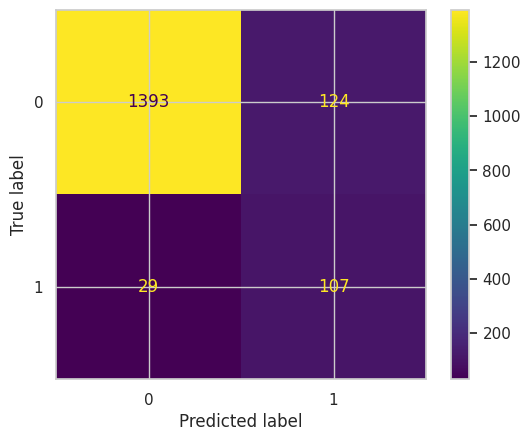

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.select_dtypes(include=np.number).corr()

# Get the correlation of each feature with the target variable
corr_with_target = corr_matrix['Target'].sort_values(ascending=False)

# Display the top 20 features most correlated with the target
print("Top 20 features correlated with Target:\n")
print(corr_with_target.head(20))

# Select features with a correlation greater than a certain threshold (e.g., 0.1)
strong_corr_features = corr_with_target[abs(corr_with_target) > 0.1].index.tolist()

# Remove the target variable from the list of features
strong_corr_features.remove('Target')

# Create new training and testing sets with only the strongly correlated features
X_train_corr = X_train[strong_corr_features]
X_test_corr = X_test[strong_corr_features]

# Initialize a new Random Forest Classifier
rfc_corr = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on the new training data
rfc_corr.fit(X_train_corr, y_train)

# Make predictions on the new test data
y_pred_corr = rfc_corr.predict(X_test_corr)

# Generate and print the classification report
print("\nClassification Report (with strongly correlated features):\n")
print(classification_report(y_test, y_pred_corr))

# Generate and display the confusion matrix
print("\nConfusion Matrix (with strongly correlated features):\n")
cm_corr = confusion_matrix(y_test, y_pred_corr)
disp_corr = ConfusionMatrixDisplay(confusion_matrix=cm_corr)
disp_corr.plot()
plt.show()

/tmp/ipython-input-2052435838.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Opportunity Category', y='Target', estimator=np.mean, palette='viridis')


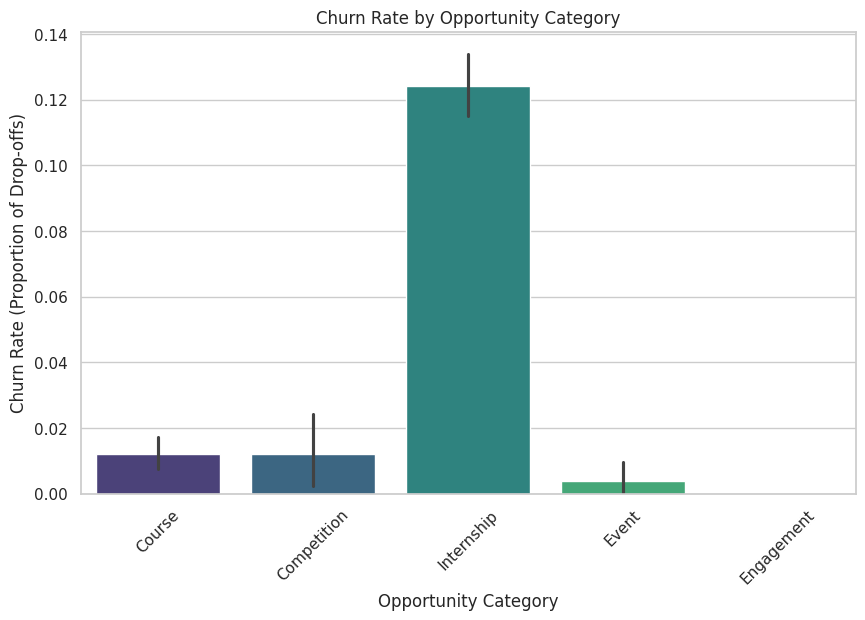

/tmp/ipython-input-2052435838.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age Bin', y='Target', estimator=np.mean, palette='mako')


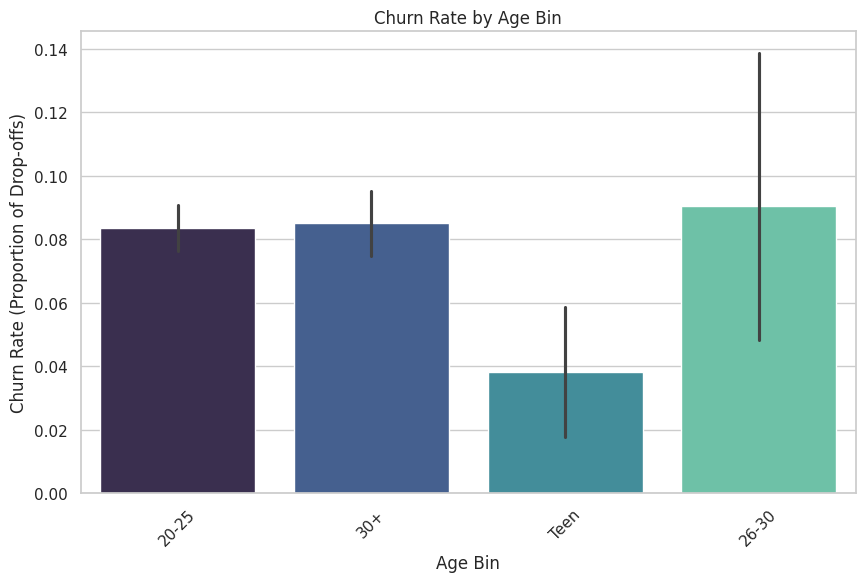

/tmp/ipython-input-2052435838.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region ', y='Target', estimator=np.mean, palette='plasma')


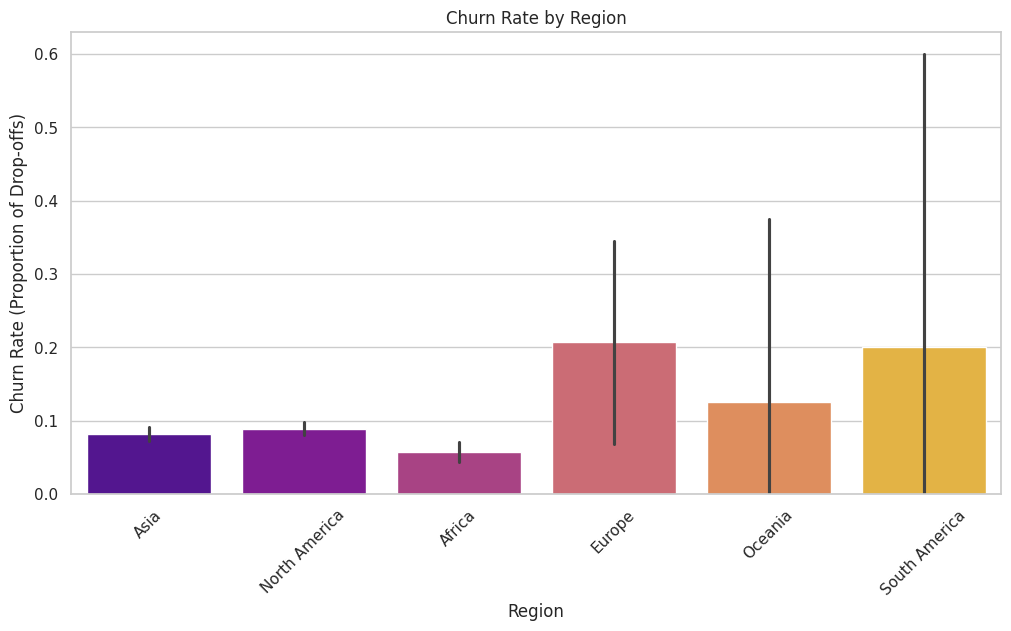

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate and plot churn rate by Opportunity Category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Opportunity Category', y='Target', estimator=np.mean, palette='viridis')
plt.title('Churn Rate by Opportunity Category')
plt.ylabel('Churn Rate (Proportion of Drop-offs)')
plt.xlabel('Opportunity Category')
plt.xticks(rotation=45)
plt.show()

# Calculate and plot churn rate by Age Bin
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Age Bin', y='Target', estimator=np.mean, palette='mako')
plt.title('Churn Rate by Age Bin')
plt.ylabel('Churn Rate (Proportion of Drop-offs)')
plt.xlabel('Age Bin')
plt.xticks(rotation=45)
plt.show()

# Calculate and plot churn rate by Region
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Region ', y='Target', estimator=np.mean, palette='plasma')
plt.title('Churn Rate by Region')
plt.ylabel('Churn Rate (Proportion of Drop-offs)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.show()